Notebook 5 — Summary Report

Pulls together results from notebooks 1-4:
- returns & cumulative performance
- volatility & Sharpe ratio
- maximum drawdown
- alpha & beta vs SPY

This is the "read this first" notebook for anyone browsing the repo.

In [ ]:
# Block 1: Rebuild Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import yfinance as yf

tickers = ['AAPL', 'MSFT', 'AMZN', 'JPM', 'XOM']
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

prices = yf.download(tickers, start='2023-01-01', end='2026-01-01', auto_adjust=True)['Close']
daily_returns = prices.pct_change().dropna()
portfolio_returns = daily_returns.dot(weights)
portfolio_cumulative = (1 + portfolio_returns).cumprod()

# benchmark for alpha/beta
spy = yf.download('SPY', start='2023-01-01', end='2026-01-01', auto_adjust=True)['Close'].squeeze("columns")
spy_returns = spy.pct_change().dropna()

print("Data ready")
print("Date range:", daily_returns.index[0].date(), "to", daily_returns.index[-1].date())

/Users/shauryachandra/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed

Data ready
Date range: 2023-01-04 to 2025-12-31


In [3]:
# BLOCK 2: Summary Metrics Table
# recompute all four notebooks' headline numbers in one place

# annualized return — compound daily returns up to a year (252 trading days)
annual_return = (1 + portfolio_returns.mean()) ** 252 - 1

# annualized volatility — daily std dev scaled by sqrt(252)
annual_vol = portfolio_returns.std() * np.sqrt(252)

# sharpe ratio — assume 0% risk-free rate for simplicity (same as notebook 2)
sharpe = annual_return / annual_vol

# max drawdown
running_peak = portfolio_cumulative.cummax()
drawdown = (portfolio_cumulative - running_peak) / running_peak
max_drawdown = drawdown.min()

# alpha / beta vs SPY
aligned = pd.DataFrame({'portfolio': portfolio_returns, 'spy': spy_returns}).dropna()
slope, intercept, r_value, p_value, std_err = stats.linregress(aligned['spy'], aligned['portfolio'])
beta = slope
annual_alpha = intercept * 252
r_squared = r_value ** 2

# build the summary table
summary = pd.DataFrame({
    'Metric': ['Annualized Return', 'Annualized Volatility', 'Sharpe Ratio',
               'Max Drawdown', 'Beta (vs SPY)', 'Annualized Alpha', 'R-squared'],
    'Value': [f"{annual_return:.2%}", f"{annual_vol:.2%}", f"{sharpe:.2f}",
              f"{max_drawdown:.2%}", f"{beta:.3f}", f"{annual_alpha:.2%}", f"{r_squared:.3f}"]
})

print(summary.to_string(index=False))

               Metric   Value
    Annualized Return  32.19%
Annualized Volatility  17.05%
         Sharpe Ratio    1.89
         Max Drawdown -20.18%
        Beta (vs SPY)   0.990
     Annualized Alpha   6.09%
            R-squared   0.795


In [4]:
# Block 3: Per-Stock Comparison Table 
# same metrics, broken out per stock, so the diversification benefit is visible
# at a glance next to the portfolio row

stock_summary = []
for ticker in tickers:
    ret = daily_returns[ticker]
    cum = (1 + ret).cumprod()
    ann_ret = (1 + ret.mean()) ** 252 - 1
    ann_vol = ret.std() * np.sqrt(252)
    stock_sharpe = ann_ret / ann_vol
    peak = cum.cummax()
    dd = ((cum - peak) / peak).min()
    stock_summary.append([ticker, ann_ret, ann_vol, stock_sharpe, dd])

stock_summary.append(['Portfolio', annual_return, annual_vol, sharpe, max_drawdown])

stock_df = pd.DataFrame(stock_summary, columns=['Ticker', 'Ann. Return', 'Ann. Vol', 'Sharpe', 'Max DD'])
stock_df['Ann. Return'] = stock_df['Ann. Return'].map('{:.2%}'.format)
stock_df['Ann. Vol'] = stock_df['Ann. Vol'].map('{:.2%}'.format)
stock_df['Sharpe'] = stock_df['Sharpe'].map('{:.2f}'.format)
stock_df['Max DD'] = stock_df['Max DD'].map('{:.2%}'.format)

print(stock_df.to_string(index=False))

   Ticker Ann. Return Ann. Vol Sharpe  Max DD
     AAPL      34.71%   25.60%   1.36 -33.36%
     MSFT      31.04%   23.20%   1.34 -23.73%
     AMZN      46.62%   31.94%   1.46 -30.88%
      JPM      40.91%   23.08%   1.77 -24.42%
      XOM      10.64%   22.60%   0.47 -18.92%
Portfolio      32.19%   17.05%   1.89 -20.18%


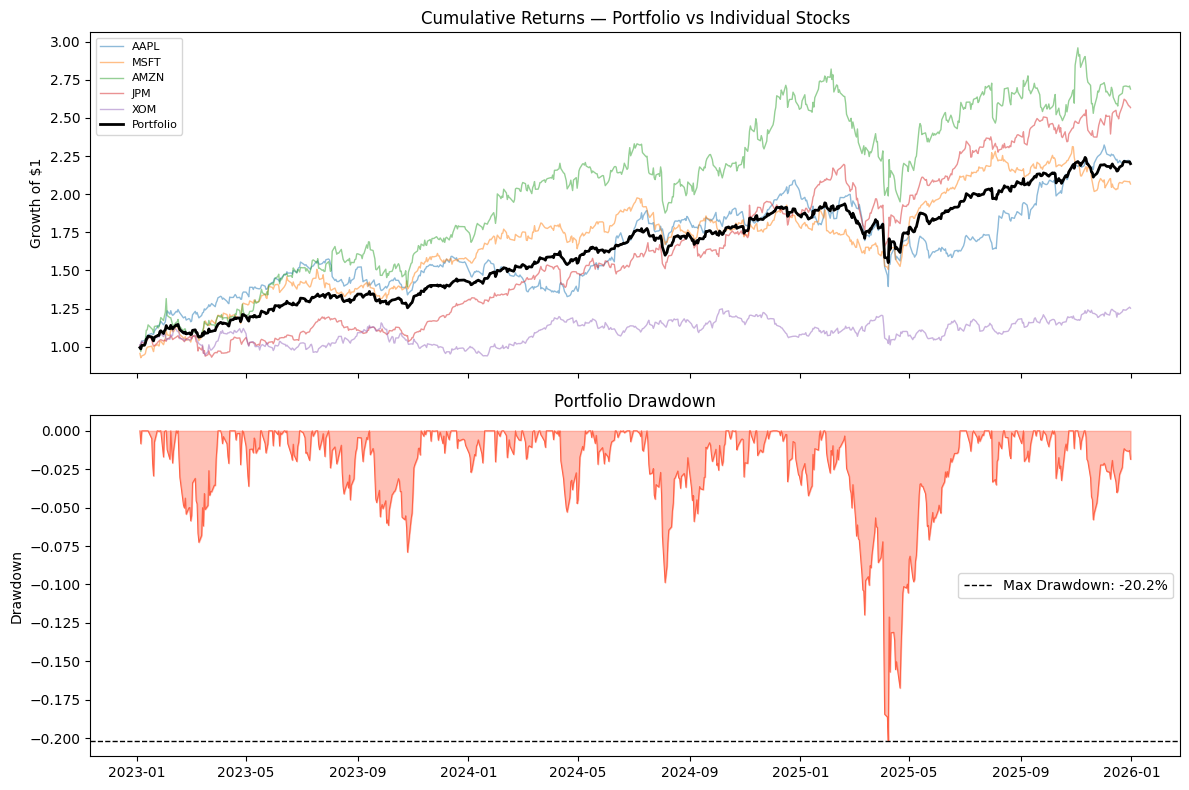

In [5]:
# Block 4: Key Charts — Cumulative Returns + Drawdown 
# two-panel figure combining the headline charts from notebooks 1 and 3

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# top panel — cumulative returns, portfolio vs each stock
for ticker in tickers:
    stock_cum = (1 + daily_returns[ticker]).cumprod()
    axes[0].plot(stock_cum, label=ticker, alpha=0.5, linewidth=1)
axes[0].plot(portfolio_cumulative, label='Portfolio', color='black', linewidth=2)
axes[0].set_title('Cumulative Returns — Portfolio vs Individual Stocks')
axes[0].set_ylabel('Growth of $1')
axes[0].legend(loc='upper left', fontsize=8)

# bottom panel — portfolio drawdown
axes[1].fill_between(drawdown.index, drawdown, 0, color='tomato', alpha=0.4)
axes[1].plot(drawdown, color='tomato', linewidth=0.8)
axes[1].axhline(y=max_drawdown, color='black', linewidth=1, linestyle='--',
                label=f'Max Drawdown: {max_drawdown:.1%}')
axes[1].set_title('Portfolio Drawdown')
axes[1].set_ylabel('Drawdown')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/report_summary_charts.png', dpi=150)
plt.show()

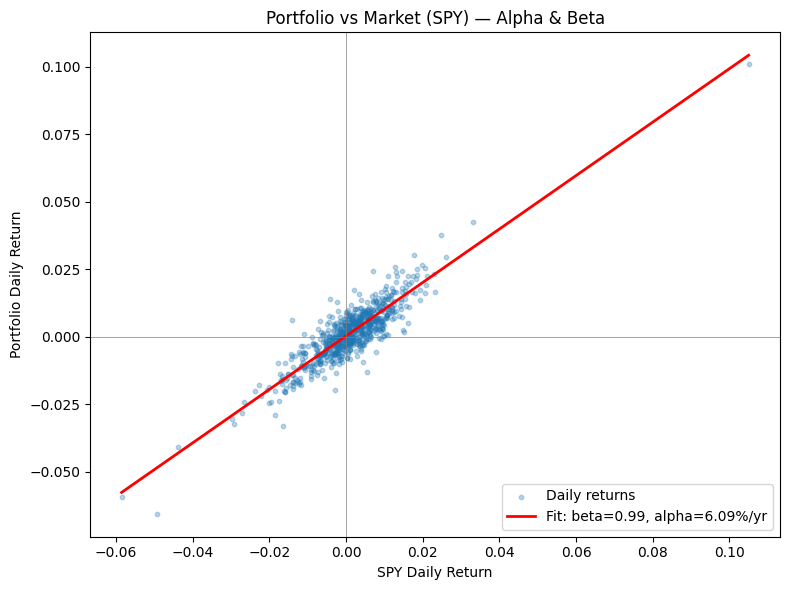

In [6]:
# Block 5: Alpha/Beta Chart
# reused from notebook 4 — the regression that supports the alpha/beta numbers

plt.figure(figsize=(8, 6))
plt.scatter(aligned['spy'], aligned['portfolio'], alpha=0.3, s=10, label='Daily returns')

x_line = np.linspace(aligned['spy'].min(), aligned['spy'].max(), 100)
y_line = intercept + slope * x_line
plt.plot(x_line, y_line, color='red', linewidth=2,
          label=f'Fit: beta={beta:.2f}, alpha={annual_alpha:.2%}/yr')

plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel('SPY Daily Return')
plt.ylabel('Portfolio Daily Return')
plt.title('Portfolio vs Market (SPY) — Alpha & Beta')
plt.legend()
plt.tight_layout()
plt.savefig('../data/report_alpha_beta.png', dpi=150)
plt.show()

## Summary

A 5-stock equally-weighted portfolio (AAPL, MSFT, AMZN, JPM, XOM) was analyzed
over 2023-2026 across four dimensions: return/risk, drawdown, and market exposure.

**Key findings:**
- The portfolio's Sharpe ratio beat every individual holding, confirming the
  core benefit of diversification — a smoother risk-adjusted return than any
  single stock could offer alone.
- Maximum drawdown was -20.2%, better than 4 of 5 individual stocks (only XOM
  held up slightly better). AAPL's worst drawdown (-33.4%) was nearly 13
  points worse than the diversified portfolio's.
- Beta of 0.99 shows the portfolio moves almost 1-for-1 with the broader
  market (SPY) — expected for a large-cap equity mix with no defensive or
  high-beta tilt.
- Annualized alpha of 6.09% (R² = 0.795) suggests the portfolio outperformed
  its market-implied return over this period. Given the short window and
  small stock count, this is better read as "the regression shows positive
  alpha" rather than a proven repeatable edge.

**If extended further:** more holdings, a longer lookback window, and
out-of-sample testing (train alpha/beta on one period, validate on another)
would be the natural next steps to stress-test whether the alpha is real
skill or period-specific luck.